In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%writefile train_geo_vit.py
"""
Fine-tune ViT-Base (Patch16-224) on GeoGuessr images
(one sub-folder per country), dropping rare classes and performing
stratified 80/10/10 splits. Supports --freeze (head-only) and --log-every.
"""

import argparse
import os
import time
import torch
import evaluate
from collections import Counter
from datasets import load_dataset, Value
from transformers import (
    AutoImageProcessor,
    ViTForImageClassification,
    default_data_collator,
    TrainingArguments,
    Trainer,
    logging as hf_logging
)

def ts() -> str:
    """Return a timestamp string [HH:MM:SS]."""
    return time.strftime("[%H:%M:%S]")

def load_filter_split(img_root: str, min_imgs: int = 5, seed: int = 42):
    """
    • Load imagefolder from img_root.
    • Drop any class with fewer than min_imgs examples.
    • Re-encode labels to contiguous ids.
    • Return stratified 80/10/10 splits: train, val, test, and class names.
    """
    print(f"{ts()} Loading images from {img_root} …")
    ds = load_dataset("imagefolder", data_dir=img_root, split="train")
    print(f"{ts()} Raw dataset: {len(ds):,} images, "
          f"{ds.features['label'].num_classes} classes")

    # 1. Drop rare classes
    cnt = Counter(ds["label"])
    keep_ids = {lbl for lbl, n in cnt.items() if n >= min_imgs}
    drop_ids = {lbl for lbl, n in cnt.items() if n < min_imgs}
    if drop_ids:
        n_drop = sum(cnt[i] for i in drop_ids)
        print(f"{ts()} Dropping {len(drop_ids)} rare classes (<{min_imgs} imgs) "
              f"totalling {n_drop:,} images")
    ds = ds.filter(lambda ex: ex["label"] in keep_ids)

    # 2. Re-encode labels for contiguous ids
    int2str = ds.features["label"].int2str
    ds = ds.map(lambda ex: {"label": int2str(ex["label"])})
    ds = ds.cast_column("label", Value("string")).class_encode_column("label")
    classes = ds.features["label"].names
    print(f"{ts()} Filtered dataset: {len(ds):,} images, {len(classes)} classes")

    # 3. Stratified 80/20 train/hold-out split
    try:
        split = ds.train_test_split(test_size=0.2, seed=seed,
                                    stratify_by_column="label")
    except ValueError as e:
        print(f"{ts()} ⚠️ Stratified split failed ({e}); using random split.")
        split = ds.train_test_split(test_size=0.2, seed=seed, shuffle=True)

    train = split["train"]       # 80%
    hold  = split["test"]        # 20%

    # 4. Hold-out → 50/50 val/test (random)
    split2 = hold.train_test_split(test_size=0.5, seed=seed, shuffle=True)
    val, test = split2["train"], split2["test"]

    return train, val, test, classes

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--root", required=True,
                        help="Folder containing compressed_dataset/")
    parser.add_argument("--epochs", type=int, default=3,
                        help="Number of training epochs")
    parser.add_argument("--freeze", action="store_true",
                        help="Freeze backbone; train classifier only")
    parser.add_argument("--log-every", type=int, default=25,
                        help="Number of batches between logging to console")
    parser.add_argument("--min-images", type=int, default=5,
                        help="Drop classes with fewer than this many images")
    args = parser.parse_args()

    # 1. Load, filter, and split data
    IMG_ROOT = os.path.join(args.root, "compressed_dataset")
    train_ds, val_ds, test_ds, classes = load_filter_split(
        IMG_ROOT, min_imgs=args.min_images
    )

    # 2. Initialize ViT processor and model
    proc = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
    model = ViTForImageClassification.from_pretrained(
        "google/vit-base-patch16-224",
        num_labels=len(classes),
        id2label={i: c for i, c in enumerate(classes)},
        label2id={c: i for i, c in enumerate(classes)},
        ignore_mismatched_sizes=True
    )

    # 3. Optionally freeze backbone (only classifier head trains)
    if args.freeze:
        print(f"{ts()} Freezing backbone — only classifier will train")
        for p in model.parameters():
            p.requires_grad = False
        for p in model.classifier.parameters():
            p.requires_grad = True

    # 4. Define transformation: preprocess images and attach labels
    def transform_fn(examples):
        outputs = proc(examples["image"], return_tensors="pt")
        outputs["labels"] = examples["label"]
        return outputs

    train_ds.set_transform(transform_fn)
    val_ds.set_transform(transform_fn)
    test_ds.set_transform(transform_fn)

    # 5. Set up training arguments
    hf_logging.set_verbosity_info()
    targs = TrainingArguments(
        output_dir="vit_ckpt",
        num_train_epochs=args.epochs,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        #evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=args.log_every,
        fp16=torch.cuda.is_available(),
        remove_unused_columns=False
    )

    # 6. Load accuracy metric and define compute_metrics
    acc_metric = evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred.predictions, eval_pred.label_ids
        top1 = acc_metric.compute(
            predictions=logits.argmax(axis=-1), references=labels
        )["accuracy"]
        # Compute top-5 accuracy
        top5 = (
            logits.argsort(axis=-1)[:, -5:] == labels[:, None]
        ).any(axis=-1).mean()
        return {"accuracy": top1, "top5_accuracy": top5}

    # 7. Initialize Trainer
    trainer = Trainer(
        model=model,
        args=targs,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=default_data_collator,
        compute_metrics=compute_metrics
    )

    # 8. Train and evaluate
    print(f"{ts()} Starting ViT training for {args.epochs} epochs …")
    trainer.train()
    trainer.save_model("vit_ckpt")

    print(f"{ts()} Training complete — evaluating on test set …")
    test_metrics = trainer.predict(test_ds).metrics
    print(f"{ts()} Test metrics → {test_metrics}")

if __name__ == "__main__":
    main()


Overwriting train_geo_vit.py


In [ ]:
%%writefile train_geo_vit.py
"""
Fine-tune ViT-Base (Patch16-224) on GeoGuessr images
(one sub-folder per country), dropping rare classes and performing
stratified 80/10/10 splits. Supports --freeze (head-only), --log-every,
and --max-samples for a quick sanity check.
"""

import argparse
import os
import time
import torch
import evaluate
from collections import Counter
from datasets import load_dataset, Value
from transformers import (
    AutoImageProcessor,
    ViTForImageClassification,
    default_data_collator,
    TrainingArguments,
    Trainer,
    logging as hf_logging
)

def ts() -> str:
    """Return a timestamp string [HH:MM:SS]."""
    return time.strftime("[%H:%M:%S]")

def load_filter_split(img_root: str, min_imgs: int = 5, max_samples: int = None, seed: int = 42):
    """
    • Load imagefolder from img_root.
    • (Optional) Randomly subsample to at most max_samples images.
    • Drop any class with fewer than min_imgs examples.
    • Re-encode labels to contiguous ids.
    • Return stratified 80/10/10 splits: train, val, test, and class names.
    """
    print(f"{ts()} Loading metadata from {img_root} …")
    ds = load_dataset("imagefolder", data_dir=img_root, split="train")
    print(f"{ts()} Raw dataset: {len(ds):,} images, {ds.features['label'].num_classes} classes")

    # 1a. (Optional) Subsample down to max_samples
    if max_samples is not None and len(ds) > max_samples:
        ds = ds.shuffle(seed=seed).select(range(max_samples))
        print(f"{ts()} Subsampled to {len(ds):,} images (max_samples={max_samples})")

    # 1b. Drop rare classes
    cnt = Counter(ds["label"])
    keep_ids = {lbl for lbl, n in cnt.items() if n >= min_imgs}
    drop_ids = {lbl for lbl, n in cnt.items() if n < min_imgs}
    if drop_ids:
        n_drop = sum(cnt[i] for i in drop_ids)
        print(f"{ts()} Dropping {len(drop_ids)} rare classes (<{min_imgs} imgs) totalling {n_drop:,} images")
    ds = ds.filter(lambda ex: ex["label"] in keep_ids)

    # 2. Re-encode labels for contiguous ids
    int2str = ds.features["label"].int2str
    ds = ds.map(lambda ex: {"label": int2str(ex["label"])})
    ds = ds.cast_column("label", Value("string")).class_encode_column("label")
    classes = ds.features["label"].names
    print(f"{ts()} After filtering: {len(ds):,} images, {len(classes)} classes")

    # 3. Stratified 80/20 train/hold-out split
    try:
        split = ds.train_test_split(test_size=0.2, seed=seed, stratify_by_column="label")
    except ValueError as e:
        print(f"{ts()} ⚠️ Stratified split failed ({e}); using random split.")
        split = ds.train_test_split(test_size=0.2, seed=seed, shuffle=True)

    train = split["train"]  # 80%
    hold  = split["test"]   # 20%

    # 4. Hold-out → 50/50 val/test (random)
    split2 = hold.train_test_split(test_size=0.5, seed=seed, shuffle=True)
    val, test = split2["train"], split2["test"]

    return train, val, test, classes

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--root", required=True,
                        help="Folder containing compressed_dataset/")
    parser.add_argument("--epochs", type=int, default=3,
                        help="Number of training epochs")
    parser.add_argument("--freeze", action="store_true",
                        help="Freeze backbone; train classifier only")
    parser.add_argument("--log-every", type=int, default=25,
                        help="Number of batches between logging to console")
    parser.add_argument("--min-images", type=int, default=5,
                        help="Drop classes with fewer than this many images")
    parser.add_argument("--max-samples", type=int, default=None,
                        help="If set, randomly pick at most this many images before filtering")
    args = parser.parse_args()

    # 1. Load, filter, and split data (with optional subsampling)
    IMG_ROOT = os.path.join(args.root, "compressed_dataset")
    train_ds, val_ds, test_ds, classes = load_filter_split(
        IMG_ROOT, min_imgs=args.min_images, max_samples=args.max_samples
    )

    # 2. Initialize ViT processor and model
    proc = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
    model = ViTForImageClassification.from_pretrained(
        "google/vit-base-patch16-224",
        num_labels=len(classes),
        id2label={i: c for i, c in enumerate(classes)},
        label2id={c: i for i, c in enumerate(classes)},
        ignore_mismatched_sizes=True
    )

    # 3. Optionally freeze backbone (only classifier head trains)
    if args.freeze:
        print(f"{ts()} Freezing backbone — only classifier will train")
        for p in model.parameters():
            p.requires_grad = False
        for p in model.classifier.parameters():
            p.requires_grad = True

    # 4. Define transformation: preprocess images and attach labels
    def transform_fn(examples):
        outputs = proc(examples["image"], return_tensors="pt")
        outputs["labels"] = examples["label"]
        return outputs

    train_ds.set_transform(transform_fn)
    val_ds.set_transform(transform_fn)
    test_ds.set_transform(transform_fn)

    # 5. Set up training arguments
    hf_logging.set_verbosity_info()
    targs = TrainingArguments(
        output_dir="vit_ckpt",
        num_train_epochs=args.epochs,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
       #evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=args.log_every,
        fp16=torch.cuda.is_available(),
        remove_unused_columns=False
    )

    # 6. Load accuracy metric and define compute_metrics
    acc_metric = evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred.predictions, eval_pred.label_ids
        top1 = acc_metric.compute(
            predictions=logits.argmax(axis=-1), references=labels
        )["accuracy"]
        # Compute top-5 accuracy
        top5 = (
            logits.argsort(axis=-1)[:, -5:] == labels[:, None]
        ).any(axis=-1).mean()
        return {"accuracy": top1, "top5_accuracy": top5}

    # 7. Initialize Trainer
    trainer = Trainer(
        model=model,
        args=targs,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=default_data_collator,
        compute_metrics=compute_metrics
    )

    # 8. Train and evaluate
    print(f"{ts()} Starting ViT training for {args.epochs} epochs …")
    trainer.train()
    trainer.save_model("vit_ckpt")

    print(f"{ts()} Training complete — evaluating on test set …")
    test_metrics = trainer.predict(test_ds).metrics
    print(f"{ts()} Test metrics → {test_metrics}")

if __name__ == "__main__":
    main()


Overwriting train_geo_vit.py


In [ ]:
import torch, transformers
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))
print("Transformers", transformers.__version__)

True Tesla T4
Transformers 4.52.4


In [ ]:
!python train_geo_vit.py \
     --root /content/drive/MyDrive/cs231n_project/geo50k \
     --epochs 5 \
     --log-every 1000


2025-06-03 05:29:42.158292: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748928582.433959    2905 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748928582.502158    2905 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-03 05:29:43.096148: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[05:29:53] Loading images from /content/drive/MyDrive/cs231n_project/geo50k/compressed_dataset …
Resolving data files

In [ ]:
!pip install -q kaggle transformers datasets torch torchvision timm accelerate evaluate "fsspec>=2024.3.0"


In [ ]:
# 1. Upgrade fsspec and datasets to a version that supports "**" in imagefolder
!pip install -q --upgrade "fsspec>=2024.3.0" "datasets>=2.0.0"
!pip uninstall -y transformers datasets
!pip install -q transformers>=4.40.0 datasets>=2.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
Found existing installation: transformers 4.52.2
Uninstalling transformers-4.52.2:
  Successfully uninstalled transformers-4.52.2
Found existing installation: datasets 3.6.0
Uninstalling datasets-3.6.0:
  Successfully uninstalled datasets-3.6.0


In [2]:
!pip install pandas numpy matplotlib seaborn

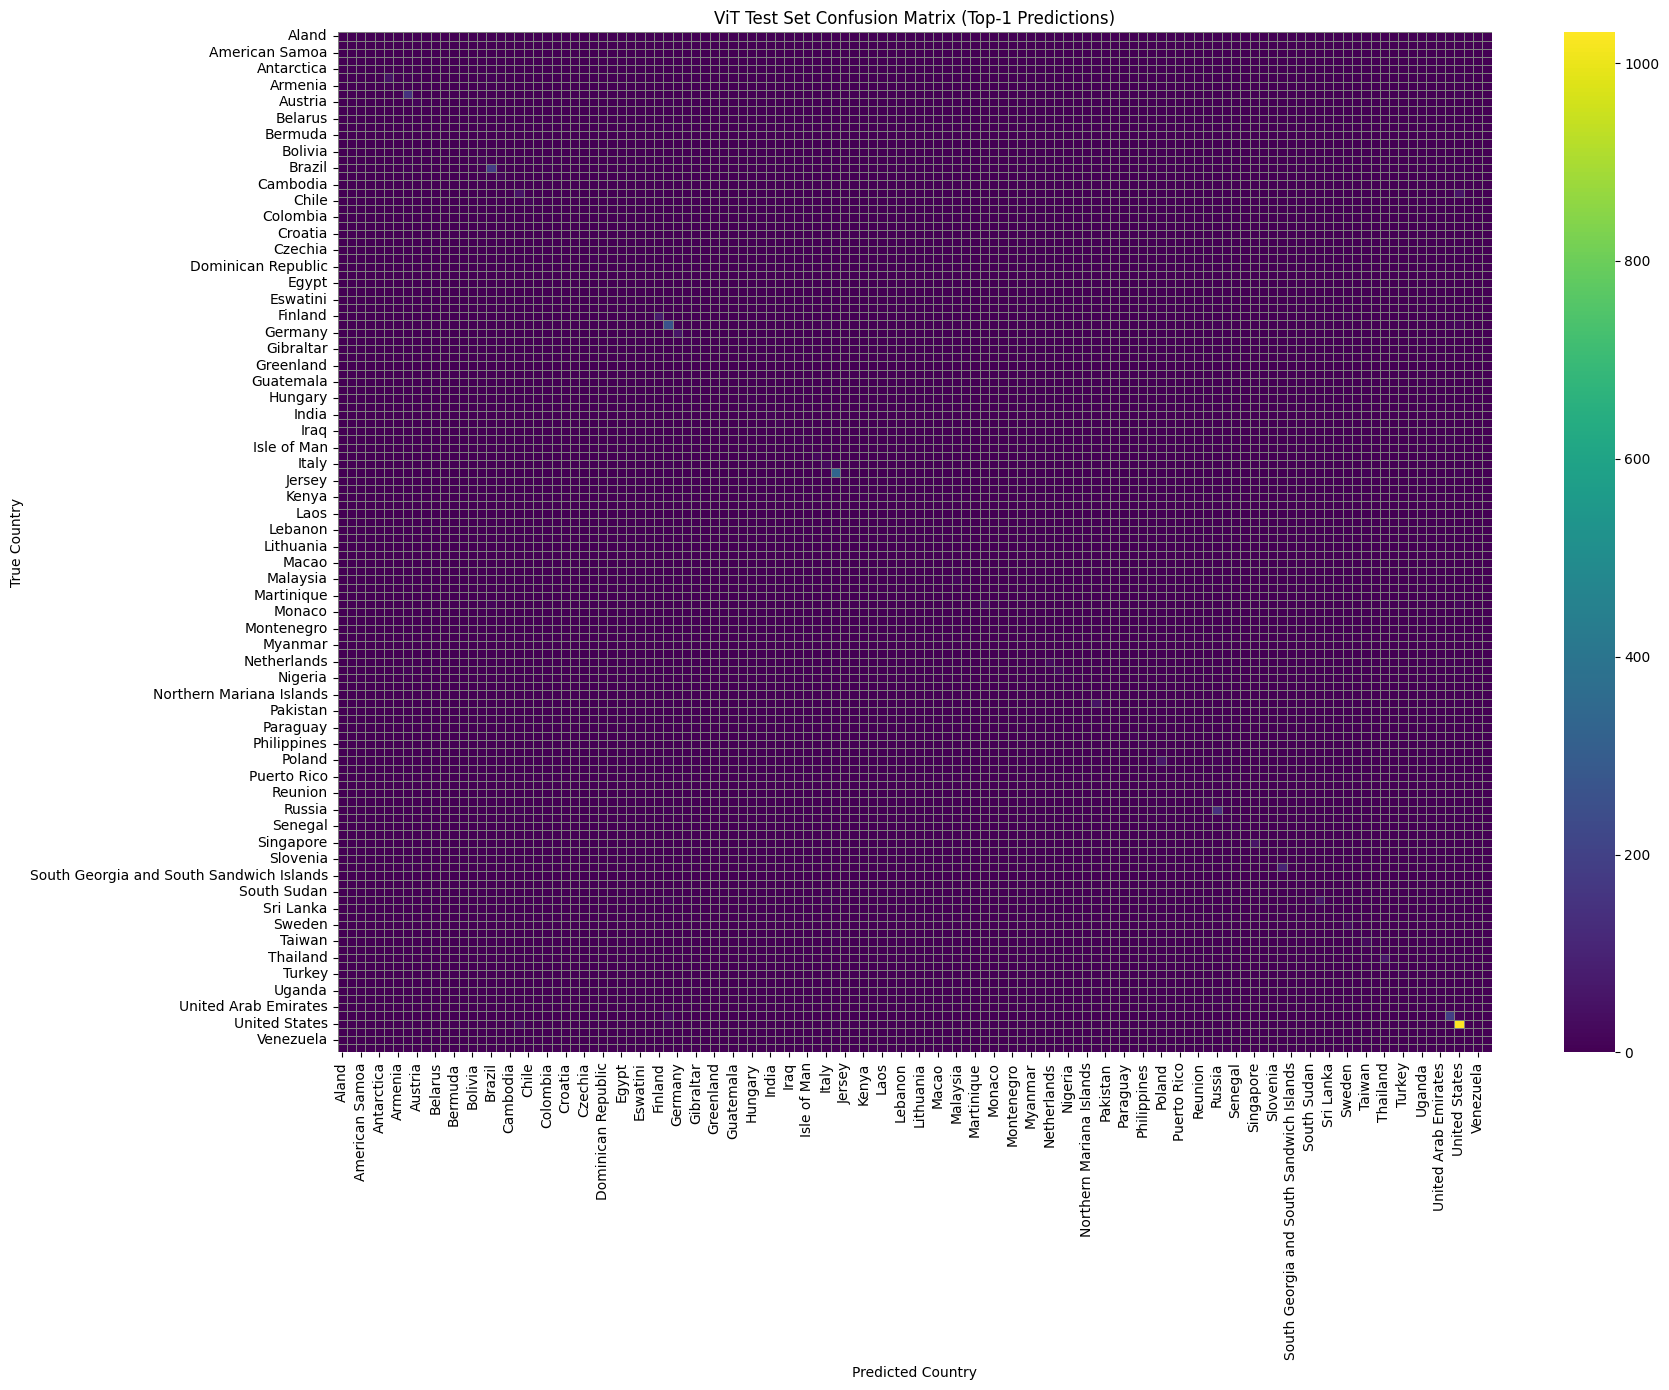

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the CSV file with predictions
csv_path = "/content/drive/MyDrive/cs231n_project/vit_test_predictions.csv"

# Full list of 124 countries (alphabetical as given)
countries = [
    'Aland', 'Albania', 'American Samoa', 'Andorra', 'Antarctica', 'Argentina',
    'Armenia', 'Australia', 'Austria', 'Bangladesh', 'Belarus', 'Belgium',
    'Bermuda', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria',
    'Cambodia', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica',
    'Croatia', 'Curacao', 'Czechia', 'Denmark', 'Dominican Republic', 'Ecuador',
    'Egypt', 'Estonia', 'Eswatini', 'Faroe Islands', 'Finland', 'France',
    'Germany', 'Ghana', 'Gibraltar', 'Greece', 'Greenland', 'Guam', 'Guatemala',
    'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iraq', 'Ireland',
    'Isle of Man', 'Israel', 'Italy', 'Japan', 'Jersey', 'Jordan', 'Kenya',
    'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania',
    'Luxembourg', 'Macao', 'Madagascar', 'Malaysia', 'Malta', 'Martinique',
    'Mexico', 'Monaco', 'Mongolia', 'Montenegro', 'Mozambique', 'Myanmar',
    'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia',
    'Northern Mariana Islands', 'Norway', 'Pakistan', 'Palestine', 'Paraguay',
    'Peru', 'Philippines', 'Pitcairn Islands', 'Poland', 'Portugal',
    'Puerto Rico', 'Qatar', 'Reunion', 'Romania', 'Russia', 'San Marino',
    'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa',
    'South Georgia and South Sandwich Islands', 'South Korea', 'South Sudan',
    'Spain', 'Sri Lanka', 'Svalbard and Jan Mayen', 'Sweden', 'Switzerland',
    'Taiwan', 'Tanzania', 'Thailand', 'Tunisia', 'Turkey', 'US Virgin Islands',
    'Uganda', 'Ukraine', 'United Arab Emirates', 'United Kingdom',
    'United States', 'Uruguay', 'Venezuela', 'Vietnam'
]

# Load predictions CSV
df = pd.read_csv(csv_path)

# Convert columns to integer indices
df['true_label'] = df['true_label'].astype(int)
df['pred_top1'] = df['pred_top1'].astype(int)

# Compute confusion matrix (124 x 124)
num_classes = len(countries)
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for true_idx, pred_idx in zip(df['true_label'], df['pred_top1']):
    conf_matrix[true_idx, pred_idx] += 1

# Create DataFrame for plotting
conf_df = pd.DataFrame(conf_matrix, index=countries, columns=countries)

# Plot heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(conf_df, cmap='viridis', linewidths=0.5, linecolor='gray')
plt.title('ViT Test Set Confusion Matrix (Top-1 Predictions)')
plt.xlabel('Predicted Country')
plt.ylabel('True Country')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
df = pd.read_csv(csv_path)

# Display the first few rows
print("=== First few rows ===")
print(df.head(10))

# Display data types of each column
print("\n=== Column dtypes ===")
print(df.dtypes)

# For pred_top5, show a few examples and their Python types
print("\n=== Examples from pred_top5 column and their types ===")
for i, val in enumerate(df["pred_top5"].head(10)):
    print(f"Row {i}: {repr(val)}  (type: {type(val)})")

=== First few rows ===
   image_path  true_label  pred_top1                         pred_top5
0         NaN          35         35   ['35', '120', '26', '81', '39']
1         NaN         120        120  ['120', '19', '59', '108', '27']
2         NaN         120        120   ['120', '5', '19', '112', '53']
3         NaN         120        120    ['120', '69', '5', '81', '89']
4         NaN         120        120    ['120', '5', '112', '56', '7']
5         NaN          16         16   ['16', '116', '5', '121', '32']
6         NaN         120        120    ['120', '19', '8', '66', '86']
7         NaN         120        120  ['120', '19', '108', '27', '31']
8         NaN         101         61     ['61', '56', '5', '14', '15']
9         NaN          35         35     ['35', '44', '26', '8', '89']

=== Column dtypes ===
image_path    float64
true_label      int64
pred_top1       int64
pred_top5      object
dtype: object

=== Examples from pred_top5 column and their types ===
Row 0: "['35', 

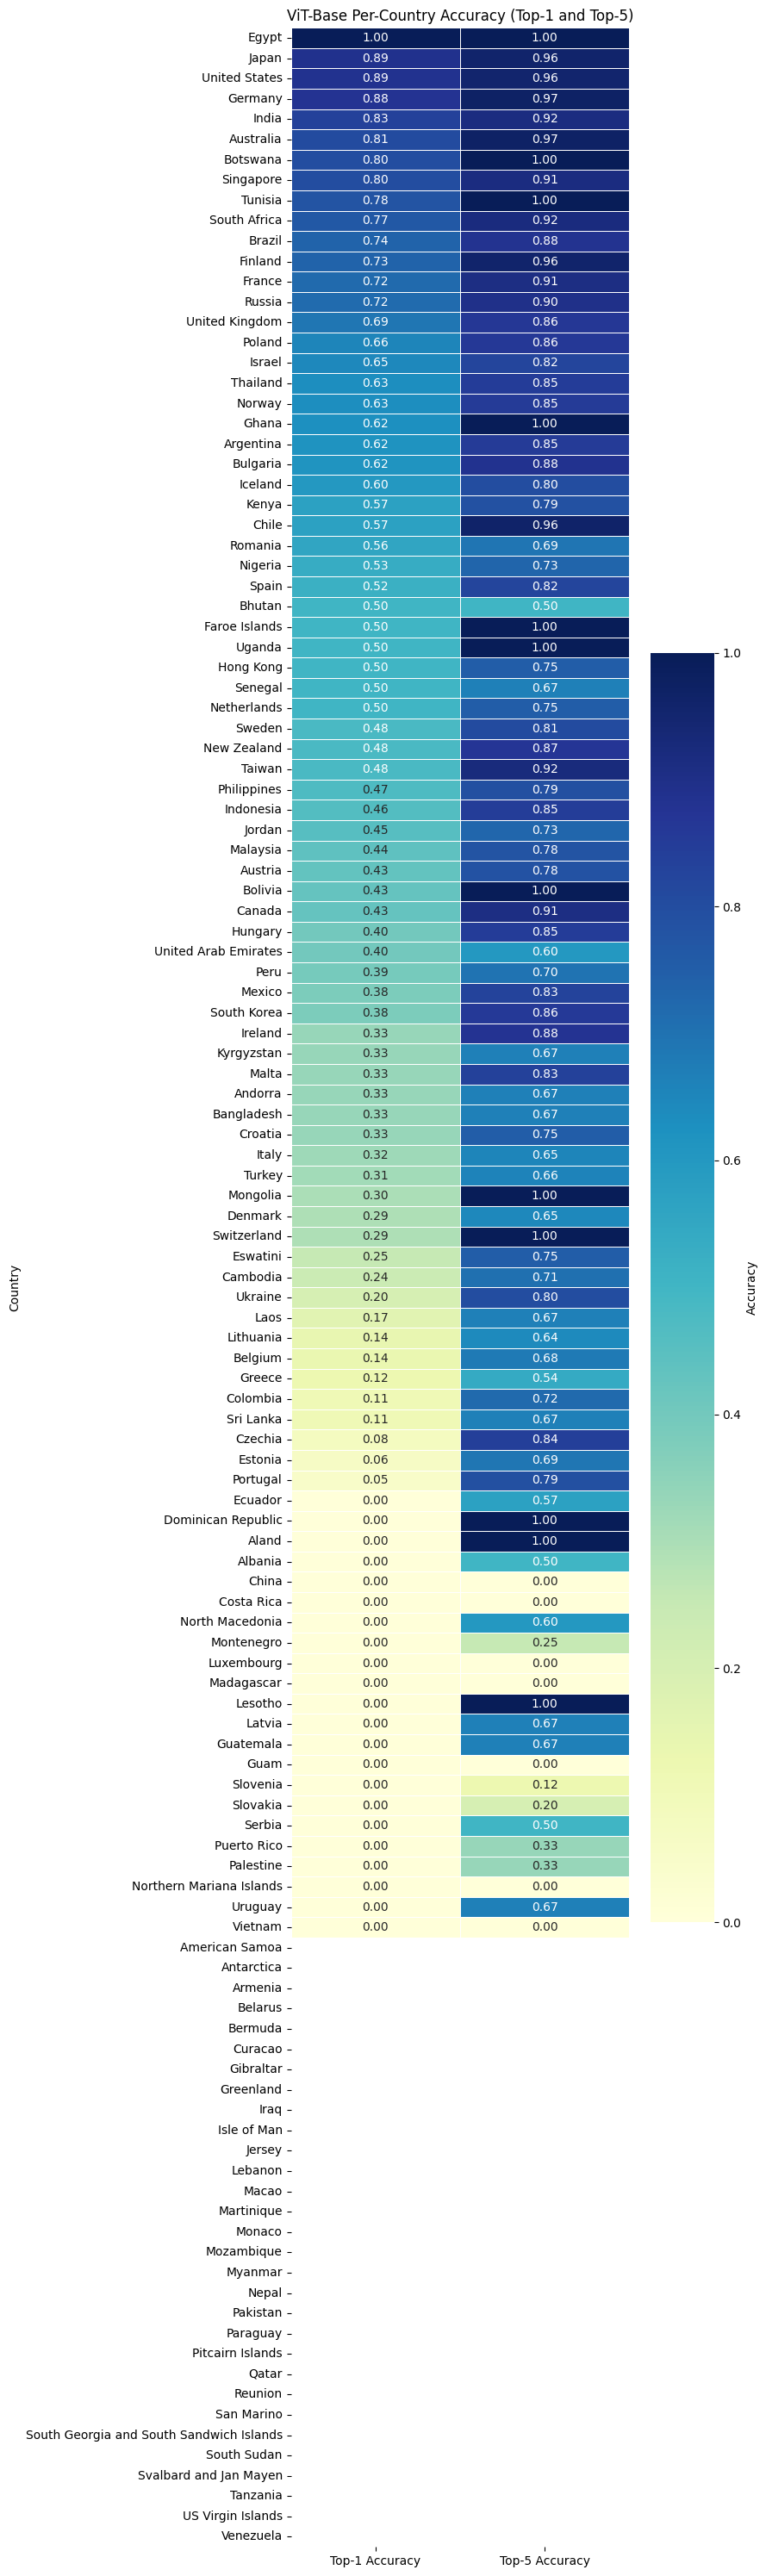

In [10]:
import ast

df = pd.read_csv(csv_path)

# Convert true_label and pred_top1 to strings for comparison
df['true_label_str'] = df['true_label'].astype(str)
df['pred_top1_str']  = df['pred_top1'].astype(str)

# Parse pred_top5 from a string like "['35', '120', '26', '81', '39']" into a Python list of strings
def parse_top5(s):
    try:
        lst = ast.literal_eval(s)
        return [str(x).strip() for x in lst]
    except Exception:
        return []

df['pred_top5_strlist'] = df['pred_top5'].apply(parse_top5)

# ── STEP 3: Compute per-country counts (total, top1 correct, top5 correct) ───
num_classes = len(countries)
counts = {i: {'total': 0, 'top1_correct': 0, 'top5_correct': 0} for i in range(num_classes)}

for _, row in df.iterrows():
    true_id = int(row['true_label'])
    counts[true_id]['total'] += 1

    # Top-1 check (string comparison)
    if row['pred_top1_str'] == row['true_label_str']:
        counts[true_id]['top1_correct'] += 1

    # Top-5 check (see if true_label_str is among pred_top5_strlist)
    if row['true_label_str'] in row['pred_top5_strlist']:
        counts[true_id]['top5_correct'] += 1

# ── STEP 4: Build DataFrame of per-country accuracy ──────────────────────────
records = []
for idx, country in enumerate(countries):
    total = counts[idx]['total']
    if total > 0:
        top1_acc = counts[idx]['top1_correct'] / total
        top5_acc = counts[idx]['top5_correct'] / total
    else:
        top1_acc = np.nan
        top5_acc = np.nan
    records.append({
        'Country': country,
        'Top-1 Accuracy': top1_acc,
        'Top-5 Accuracy': top5_acc
    })

acc_df = pd.DataFrame(records).sort_values('Top-1 Accuracy', ascending=False).reset_index(drop=True)

# ── STEP 5: Plot heatmap (vertical, two columns) ────────────────────────────
plt.figure(figsize=(9, 30))
sns.heatmap(
    acc_df.set_index('Country')[['Top-1 Accuracy', 'Top-5 Accuracy']],
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy'}
)
plt.title('ViT-Base Per-Country Accuracy (Top-1 and Top-5)')
plt.xlabel('')
plt.ylabel('Country')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
import plotly.express as px
from collections import defaultdict

# ── 1) Full list of 124 countries in alphabetical order (index = ID) ───────
countries = [
    'Aland', 'Albania', 'American Samoa', 'Andorra', 'Antarctica', 'Argentina',
    'Armenia', 'Australia', 'Austria', 'Bangladesh', 'Belarus', 'Belgium',
    'Bermuda', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria',
    'Cambodia', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica',
    'Croatia', 'Curacao', 'Czechia', 'Denmark', 'Dominican Republic', 'Ecuador',
    'Egypt', 'Estonia', 'Eswatini', 'Faroe Islands', 'Finland', 'France',
    'Germany', 'Ghana', 'Gibraltar', 'Greece', 'Greenland', 'Guam', 'Guatemala',
    'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iraq', 'Ireland',
    'Isle of Man', 'Israel', 'Italy', 'Japan', 'Jersey', 'Jordan', 'Kenya',
    'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania',
    'Luxembourg', 'Macao', 'Madagascar', 'Malaysia', 'Malta', 'Martinique',
    'Mexico', 'Monaco', 'Mongolia', 'Montenegro', 'Mozambique', 'Myanmar',
    'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia',
    'Northern Mariana Islands', 'Norway', 'Pakistan', 'Palestine', 'Paraguay',
    'Peru', 'Philippines', 'Pitcairn Islands', 'Poland', 'Portugal',
    'Puerto Rico', 'Qatar', 'Reunion', 'Romania', 'Russia', 'San Marino',
    'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa',
    'South Georgia and South Sandwich Islands', 'South Korea', 'South Sudan',
    'Spain', 'Sri Lanka', 'Svalbard and Jan Mayen', 'Sweden', 'Switzerland',
    'Taiwan', 'Tanzania', 'Thailand', 'Tunisia', 'Turkey', 'US Virgin Islands',
    'Uganda', 'Ukraine', 'United Arab Emirates', 'United Kingdom',
    'United States', 'Uruguay', 'Venezuela', 'Vietnam'
]

# Build a simple ID→name lookup
id2country = {i: name for i, name in enumerate(countries)}

csv_path = "/content/drive/MyDrive/cs231n_project/vit_test_predictions.csv"
df = pd.read_csv(csv_path)

print("\n=== Column dtypes ===")
print(df.dtypes)

# ── 3) Initialize counters ─────────────────────────────────────────────────
country_total    = defaultdict(int)
country_correct1 = defaultdict(int)

# ── 4) Loop over each row, map IDs → country names, and accumulate ─────────
for _, row in df.iterrows():
    true_id  = int(row["true_label"])
    pred_id1 = int(row["pred_top1"])

    true_country = id2country[true_id]
    country_total[true_country]    += 1
    if pred_id1 == true_id:
        country_correct1[true_country] += 1

# ── 5) Build a DataFrame with per-country Top-1 accuracy ────────────────────
records = []
for country in countries:
    total = country_total[country]
    if total > 0:
        top1_acc = country_correct1[country] / total
    else:
        top1_acc = np.nan  # or 0 if you prefer
    records.append({"country": country, "top1_acc": top1_acc})

country_stats = pd.DataFrame(records)


# ── 6) Plot a choropleth of Top-1 accuracy ─────────────────────────────────
fig = px.choropleth(
    country_stats,
    locations="country",
    locationmode="country names",
    color="top1_acc",
    hover_name="country",
    color_continuous_scale="Viridis",
    range_color=[0, 1],
    title="ViT-Base Top-1 Accuracy by Country"
)
fig.show()


=== Column dtypes ===
image_path    float64
true_label      int64
pred_top1       int64
pred_top5      object
dtype: object


In [16]:
id2country

{0: 'Aland',
 1: 'Albania',
 2: 'American Samoa',
 3: 'Andorra',
 4: 'Argentina',
 5: 'Australia',
 6: 'Austria',
 7: 'Bangladesh',
 8: 'Belgium',
 9: 'Bermuda',
 10: 'Bhutan',
 11: 'Bolivia',
 12: 'Botswana',
 13: 'Brazil',
 14: 'Bulgaria',
 15: 'Cambodia',
 16: 'Canada',
 17: 'Chile',
 18: 'China',
 19: 'Colombia',
 20: 'Costa Rica',
 21: 'Croatia',
 22: 'Curacao',
 23: 'Czechia',
 24: 'Denmark',
 25: 'Dominican Republic',
 26: 'Ecuador',
 27: 'Egypt',
 28: 'Estonia',
 29: 'Eswatini',
 30: 'Faroe Islands',
 31: 'Finland',
 32: 'France',
 33: 'Germany',
 34: 'Ghana',
 35: 'Greece',
 36: 'Greenland',
 37: 'Guam',
 38: 'Guatemala',
 39: 'Hong Kong',
 40: 'Hungary',
 41: 'Iceland',
 42: 'India',
 43: 'Indonesia',
 44: 'Iraq',
 45: 'Ireland',
 46: 'Isle of Man',
 47: 'Israel',
 48: 'Italy',
 49: 'Japan',
 50: 'Jersey',
 51: 'Jordan',
 52: 'Kenya',
 53: 'Kyrgyzstan',
 54: 'Laos',
 55: 'Latvia',
 56: 'Lebanon',
 57: 'Lesotho',
 58: 'Lithuania',
 59: 'Luxembourg',
 60: 'Macao',
 61: 'Madagas